# Question 3: ResNet18 from scratch (MNIST / CIFAR10 / CIFAR100)

## Setup

In [1]:

# Setup: imports, seeds, device

!pip install -q torch torchvision scikit-learn matplotlib pandas

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

QUICK_TEST = False


Using device: cuda


## Data loading & preprocessing

In [2]:

# Data loading & preprocessing


DATASET_INFO = {
    'MNIST':    {'num_classes': 10,  'grayscale': True},
    'CIFAR10':  {'num_classes': 10,  'grayscale': False},
    'CIFAR100': {'num_classes': 100, 'grayscale': False},
}

def build_transform(grayscale):
    steps = []
    if grayscale:
        steps.append(transforms.Grayscale(num_output_channels=3))
        steps.append(transforms.Resize((32, 32)))
    steps.append(transforms.ToTensor())
    steps.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
    return transforms.Compose(steps)

def get_dataloaders(dataset_name, batch_size=32, data_root='./data', quick_test=False):
    info = DATASET_INFO[dataset_name]
    transform = build_transform(info['grayscale'])

    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(data_root, train=False, download=True, transform=transform)
        classes = [str(i) for i in range(10)]
    elif dataset_name == 'CIFAR10':
        train_set = torchvision.datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    elif dataset_name == 'CIFAR100':
        train_set = torchvision.datasets.CIFAR100(data_root, train=True, download=True, transform=transform)
        test_set = torchvision.datasets.CIFAR100(data_root, train=False, download=True, transform=transform)
        classes = train_set.classes
    else:
        raise ValueError(f"Unknown dataset {dataset_name}")

    if quick_test:
        train_set = Subset(train_set, range(1024))
        test_set = Subset(test_set, range(512))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader, info['num_classes'], classes


## Model definition

In [3]:

# Model: ResNet18

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_residual:
            out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, use_residual=True):
        super().__init__()
        self.in_planes = 64
        self.use_residual = use_residual

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s, use_residual=self.use_residual))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out
model = ResNet18(num_classes=10)
print(model)


ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

## Training & evaluation utilities

In [4]:

# Training loop

def train_model(model, train_loader, epochs=10, lr=0.01, device=device, verbose=True):
    model.to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    model.train()
    history = []
    start = time.time()
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        epoch_loss, epoch_acc = running_loss / total, correct / total
        history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'train_acc': epoch_acc})
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs} | loss: {epoch_loss:.4f} | train acc: {epoch_acc:.4f}")

    training_time = time.time() - start
    if verbose:
        print(f"Training time: {training_time:.2f} seconds")
    return history, training_time


def evaluate_model(model, test_loader, device=device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
    }
    print(f"Test Accuracy: {metrics['accuracy']:.4f} | Precision: {metrics['precision']:.4f} "
          f"| Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}")
    return metrics


def visualize_prediction(model, test_loader, classes, device=device, unnormalize=True):
    dataset = test_loader.dataset
    idx = np.random.randint(len(dataset))
    image, label = dataset[idx]

    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()

    img = image.permute(1, 2, 0).cpu().numpy()
    if unnormalize:
        img = img * 0.5 + 0.5
    plt.figure(figsize=(3, 3))
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"True: {classes[label]} | Predicted: {classes[pred]}", fontsize=10)
    plt.axis('off')
    plt.show()


def plot_confusion_matrix(model, test_loader, classes, device=device, dataset_name=''):

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            logits = model(images)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig_size = 4 if len(classes) <= 10 else 8   # bigger canvas for CIFAR100's 100 classes
    plt.figure(figsize=(fig_size, fig_size))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion matrix — {dataset_name}", fontsize=10)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    if len(classes) <= 10:
        plt.xticks(range(len(classes)), classes, rotation=45, ha='right', fontsize=7)
        plt.yticks(range(len(classes)), classes, fontsize=7)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## Train & evaluate across MNIST, CIFAR10, CIFAR100


===== ResNet18 (from scratch) | Dataset: MNIST =====


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.85MB/s]


Epoch  1/10 | loss: 0.1076 | train acc: 0.9667
Epoch  2/10 | loss: 0.0333 | train acc: 0.9900
Epoch  3/10 | loss: 0.0221 | train acc: 0.9933
Epoch  4/10 | loss: 0.0143 | train acc: 0.9951
Epoch  5/10 | loss: 0.0120 | train acc: 0.9961
Epoch  6/10 | loss: 0.0074 | train acc: 0.9974
Epoch  7/10 | loss: 0.0074 | train acc: 0.9975
Epoch  8/10 | loss: 0.0062 | train acc: 0.9981
Epoch  9/10 | loss: 0.0044 | train acc: 0.9987
Epoch 10/10 | loss: 0.0022 | train acc: 0.9993
Training time: 619.04 seconds
Test Accuracy: 0.9955 | Precision: 0.9954 | Recall: 0.9955 | F1: 0.9955


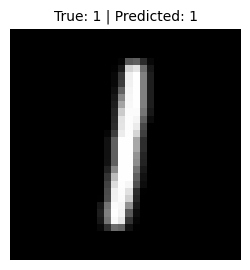

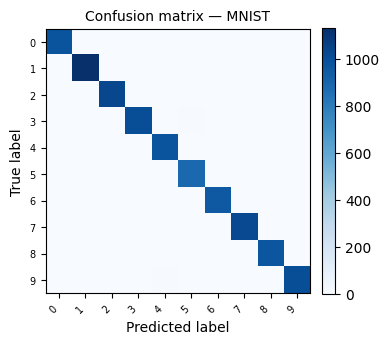


===== ResNet18 (from scratch) | Dataset: CIFAR10 =====


100%|██████████| 170M/170M [02:59<00:00, 949kB/s]


Epoch  1/10 | loss: 1.3817 | train acc: 0.5032
Epoch  2/10 | loss: 0.8112 | train acc: 0.7167
Epoch  3/10 | loss: 0.5847 | train acc: 0.7989
Epoch  4/10 | loss: 0.4420 | train acc: 0.8458
Epoch  5/10 | loss: 0.3368 | train acc: 0.8829
Epoch  6/10 | loss: 0.2514 | train acc: 0.9115
Epoch  7/10 | loss: 0.1821 | train acc: 0.9350
Epoch  8/10 | loss: 0.1344 | train acc: 0.9526
Epoch  9/10 | loss: 0.0933 | train acc: 0.9667
Epoch 10/10 | loss: 0.0737 | train acc: 0.9741
Training time: 504.08 seconds
Test Accuracy: 0.8296 | Precision: 0.8359 | Recall: 0.8296 | F1: 0.8275


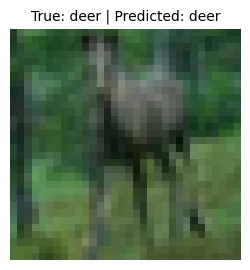

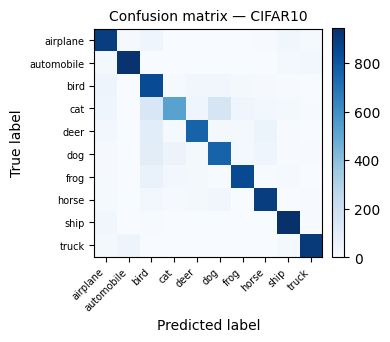


===== ResNet18 (from scratch) | Dataset: CIFAR100 =====


100%|██████████| 169M/169M [07:38<00:00, 368kB/s]


Epoch  1/10 | loss: 3.6454 | train acc: 0.1393
Epoch  2/10 | loss: 2.7203 | train acc: 0.2988
Epoch  3/10 | loss: 2.1294 | train acc: 0.4251
Epoch  4/10 | loss: 1.7203 | train acc: 0.5193
Epoch  5/10 | loss: 1.3901 | train acc: 0.5996
Epoch  6/10 | loss: 1.0835 | train acc: 0.6795
Epoch  7/10 | loss: 0.8061 | train acc: 0.7540
Epoch  8/10 | loss: 0.5365 | train acc: 0.8318
Epoch  9/10 | loss: 0.3321 | train acc: 0.8959
Epoch 10/10 | loss: 0.2060 | train acc: 0.9370
Training time: 511.98 seconds
Test Accuracy: 0.5362 | Precision: 0.5619 | Recall: 0.5362 | F1: 0.5326


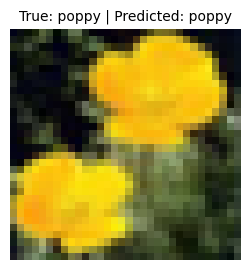

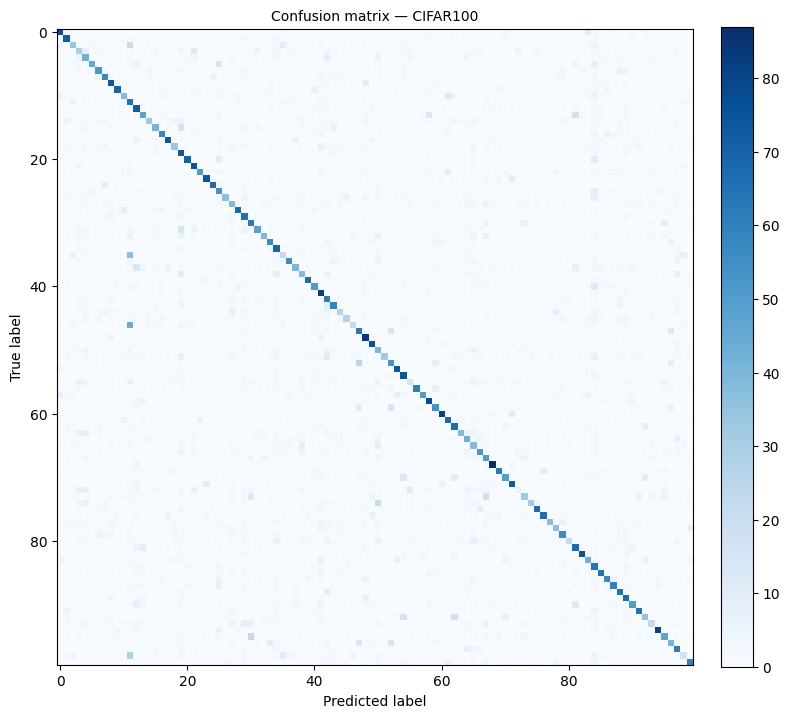


===== Summary: ResNet18 =====
          accuracy  precision    recall        f1  training_time_sec
MNIST       0.9955   0.995443  0.995462  0.995450         619.039376
CIFAR10     0.8296   0.835945  0.829600  0.827545         504.077113
CIFAR100    0.5362   0.561911  0.536200  0.532647         511.976941


In [5]:

# Run Question 3 across all three datasets


EPOCHS = 2 if QUICK_TEST else 10

results = {}
for ds_name in ['MNIST', 'CIFAR10', 'CIFAR100']:
    print(f"\n===== ResNet18 (from scratch) | Dataset: {ds_name} =====")
    train_loader, test_loader, num_classes, classes = get_dataloaders(
        ds_name, batch_size=32, quick_test=QUICK_TEST
    )
    model = ResNet18(num_classes=num_classes)

    history, train_time = train_model(model, train_loader, epochs=EPOCHS, lr=0.01)
    metrics = evaluate_model(model, test_loader)
    metrics['training_time_sec'] = train_time
    results[ds_name] = metrics

    visualize_prediction(model, test_loader, classes)
    plot_confusion_matrix(model, test_loader, classes, dataset_name=ds_name)

summary_df = pd.DataFrame(results).T
print("\n===== Summary: ResNet18 =====")
print(summary_df)


## Ablation study


--- Config: ResNet18 (with skip connections) ---
Test Accuracy: 0.8094 | Precision: 0.8117 | Recall: 0.8094 | F1: 0.8078

--- Config: PlainNet18 (skip connections removed) ---
Test Accuracy: 0.7827 | Precision: 0.8181 | Recall: 0.7827 | F1: 0.7884

===== Ablation summary: residual connections (CIFAR10) =====
                                       accuracy  precision  recall        f1
ResNet18 (with skip connections)         0.8094   0.811697  0.8094  0.807847
PlainNet18 (skip connections removed)    0.7827   0.818092  0.7827  0.788413


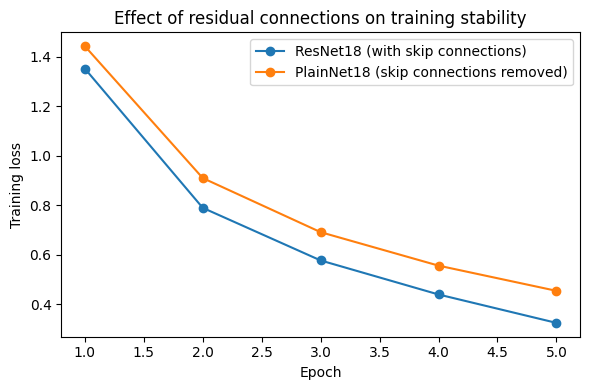

In [6]:

# Ablation study:
ablation_epochs = 2 if QUICK_TEST else 5

train_loader, test_loader, num_classes, classes = get_dataloaders(
    'CIFAR10', batch_size=32, quick_test=QUICK_TEST
)

histories = {}
ablation_results = {}
for name, use_residual in [('ResNet18 (with skip connections)', True),
                            ('PlainNet18 (skip connections removed)', False)]:
    print(f"\n--- Config: {name} ---")
    model = ResNet18(num_classes=num_classes, use_residual=use_residual)
    history, _ = train_model(model, train_loader, epochs=ablation_epochs, lr=0.01, verbose=False)
    metrics = evaluate_model(model, test_loader)
    histories[name] = history
    ablation_results[name] = metrics

ablation_df = pd.DataFrame(ablation_results).T
print("\n===== Ablation summary: residual connections (CIFAR10) =====")
print(ablation_df)

plt.figure(figsize=(6, 4))
for name, history in histories.items():
    losses = [h['loss'] for h in history]
    plt.plot(range(1, len(losses) + 1), losses, marker='o', label=name)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Effect of residual connections on training stability')
plt.legend()
plt.tight_layout()
plt.show()



### Discussion: residual connections and training stability

- Each `BasicBlock` computes `out = ReLU(F(x) + x)` instead of just
  `out = ReLU(F(x))`. During backpropagation the derivative of the skip
  path is `d(x)/dx = 1`, so gradients always have a direct, unattenuated
  route back to earlier layers even if `F` locally has a very small or
  vanishing gradient. This is the well-known reason residual connections
  make much deeper networks trainable with plain SGD.
- The `PlainNet18` ablation above removes this shortcut path; expect (and
  comment on, once you have run the full experiment) a noisier/slower-
  decreasing training loss curve and/or lower final accuracy than the
  residual version, especially as depth increases.
- Compared with the VGG16 in Question 2, ResNet's residual design lets it
  reach comparable or better accuracy while typically training more
  stably, illustrating why residual connections became a standard
  building block after the 2015 ResNet paper.


###Analysis:
ResNet18 (Residual Networks)Vanishing Gradient Problem: In standard deep networks, backpropagating error gradients through many sequential layers causes the gradient signal to exponentially diminish ($\rightarrow 0$), preventing early layers from updating effectively.Identity Shortcut Formulation: ResNet solves this optimization bottleneck by introducing residual skip connections defined by the formulation:$$y = \mathcal{F}(x, \{W_i\}) + x$$where $x$ is the input and $\mathcal{F}$ represents the residual mapping to be learned.Optimization Advantage: The additive shortcut $x$ allows gradients to flow directly through the network without attenuation during backpropagation. This enables stable training, faster convergence, and superior performance even as network depth increases.